# Workshop D.2: Evaluating Learned Representations
## Notebook 5.c — Disentanglement of representations


In [57]:
# --- Imports: standard libs, numpy/pandas, plotting, torch, torchvision, sklearn
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
from torchvision.models import (resnet18, resnet34, ResNet18_Weights, ResNet34_Weights)
from torch.utils.data import random_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error
import importlib
import matplotlib.pyplot as plt
# Suppress noisy warnings in notebook output
warnings.filterwarnings("ignore")

# 1 (and 2). DL and load Dataset of intereset
## 1.1 DL and Load properly into a D={X,Y}

In [2]:
from data import download_dsprites, load_dSprites
DSPRITES_PATH = download_dsprites()
dsprites = load_dSprites(DSPRITES_PATH)

File already exists: data/dsprites/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz
Keys in dataset:
['metadata', 'imgs', 'latents_classes', 'latents_values']

Shapes:
imgs: (737280, 64, 64)
latents_classes: (737280, 6)
latents_values: (737280, 6)

Latent names from metadata:
('color', 'shape', 'scale', 'orientation', 'posX', 'posY')

Latent sizes from metadata:
[ 1  3  6 40 32 32]

Tensor shapes:
X: torch.Size([737280, 1, 64, 64])
Y_classes: torch.Size([737280, 6])
Y_values: torch.Size([737280, 6])

Factor index:
0: color        |  1 unique class values | [0]
1: shape        |  3 unique class values | [0, 1, 2]
2: scale        |  6 unique class values | [0, 1, 2, 3, 4, 5]
3: rotation     | 40 unique class values | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
4: x_position   | 32 unique class values | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 

#### Bellow: we will convert it into D={X, Y=[Y_classes, Y_values] }. 


$$\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N}$$

where:

$$x_i \in \mathbb{R}^{1\times64\times64}$$
and
$$y_i =
[
y_{\text{color}},
y_{\text{shape}},
y_{\text{scale}},
y_{\text{rotation}},
y_{x\text{-pos}},
y_{y\text{-pos}}
]$$

In [3]:
dataset = dsprites["dataset"]
X = dsprites["X"]
Y_classes = dsprites["Y_classes"]
Y_values = dsprites["Y_values"]
metadata = dsprites["metadata"]
FACTOR_INDEX = dsprites["factor_index"]

### the way the data is arranged and we can get the FVs directly:
Then for each disentanglement probe:
$$FV_k(x_i)=y_{i,k}$$
For example:
$$FV_{\text{shape}}(x_i)=y_{i,\text{shape}}$$

In [4]:
dataset.get_factor(199090, "scale")

tensor(4)

## 1.2 Now Train/Val/Test split and load into a pytorch Dataloader

In [4]:
# ------------------------------------------------------------# Train / validation / test split# ------------------------------------------------------------
N = len(dataset)
n_train = int(0.8 * N)
n_val = int(0.1 * N)
n_test = N - n_train - n_val

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split( dataset, [n_train, n_val, n_test], generator=generator)

print("\nSplit sizes:")
print("train:", len(train_dataset))
print("val:  ", len(val_dataset))
print("test: ", len(test_dataset))


# ------------------------------------------------------------# DataLoaders# ------------------------------------------------------------
BATCH_SIZE = 128
train_loader = DataLoader( train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True,)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True,)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True,)


Split sizes:
train: 589824
val:   73728
test:  73728


###  Evaluating one example to make sure all is good and works as expected

In [6]:
# ------------------------------------------------------------# Inspect one batch# ------------------------------------------------------------

batch = next(iter(train_loader))

batch_x = batch["x"]              # [B, 1, 64, 64]
batch_y = batch["y"]              # [B, 6]
batch_y_values = batch["y_values"]  # [B, 6]

print("\nBatch:")
print("batch_x:", batch_x.shape)
print("batch_y:", batch_y.shape)
print("batch_y_values:", batch_y_values.shape)

print("\nFirst 5 factor vectors:")
print(batch_y[:5])

print("\nAccess individual factors:")
for name, idx in FACTOR_INDEX.items():
    print(f"{name:12s}:", batch_y[:10, idx].tolist())


Batch:
batch_x: torch.Size([128, 1, 64, 64])
batch_y: torch.Size([128, 6])
batch_y_values: torch.Size([128, 6])

First 5 factor vectors:
tensor([[ 0,  2,  1, 25,  4, 13],
        [ 0,  0,  4,  1, 29,  6],
        [ 0,  0,  4, 22, 29, 16],
        [ 0,  2,  5, 15, 12, 21],
        [ 0,  0,  4, 34,  9, 10]])

Access individual factors:
color       : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
shape       : [2, 0, 0, 2, 0, 0, 1, 0, 1, 0]
scale       : [1, 4, 4, 5, 4, 4, 4, 0, 4, 3]
rotation    : [25, 1, 22, 15, 34, 3, 14, 36, 5, 23]
x_position  : [4, 29, 29, 12, 9, 0, 11, 21, 1, 18]
y_position  : [13, 6, 16, 21, 10, 9, 27, 9, 2, 1]


In [7]:
# ------------------------------------------------------------# Example: choose one factor for a probe# ------------------------------------------------------------

# Example target: shape
factor_name = "shape"
factor_idx = FACTOR_INDEX[factor_name]

x_probe = batch_x
y_probe = batch_y[:, factor_idx]

print(f"\nProbe target: {factor_name}")
print("x_probe:", x_probe.shape)
print("y_probe:", y_probe.shape)
print("unique labels in batch:", torch.unique(y_probe).tolist())


Probe target: shape
x_probe: torch.Size([128, 1, 64, 64])
y_probe: torch.Size([128])
unique labels in batch: [0, 1, 2]


tensor([ 0,  2,  1, 25,  4, 13])


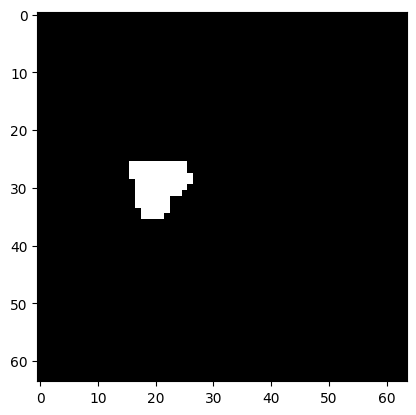

tensor([ 0,  0,  4, 18,  6,  9])


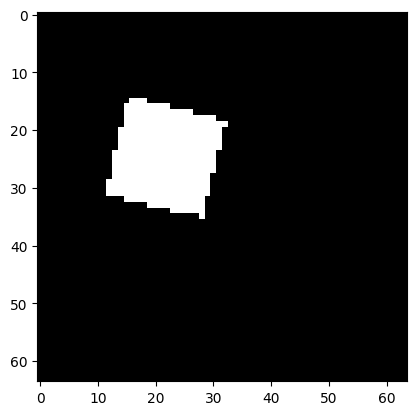

In [8]:
index_of_smaple_of_interest=0
print(batch_y[index_of_smaple_of_interest,:])
plt.imshow(batch_x[index_of_smaple_of_interest,:,:,:].squeeze(0),cmap='Greys_r')
plt.show()
index_of_smaple_of_interest=127
print(batch_y[index_of_smaple_of_interest,:])
plt.imshow(batch_x[index_of_smaple_of_interest,:,:,:].squeeze(0),cmap='Greys_r')

# 3 Models

## 3.1 Define the models
model definitions are in the model.py file. We have:

Model_1: Autoencoder : needs training<br>
Model_2: BetaVAE : needs training<br>
Model_3: FactorVAE : needs training<br>
Model_4: ResNet18Encoder : pretrained<br>

In [46]:
# ===== Model 1: AE (Autoencoder)# ================================================================
from models import Autoencoder
from utils import count_parameters, freeze_model
model_ae = Autoencoder(latent_dim=16)

x = torch.randn(8, 1, 64, 64)
x_logits, z = model_ae(x)
z= model_ae.encode(x) # this is how we can access the z directly
print("Input x:", x.shape)
print("Latent z:", z.shape)
print("Reconstruction logits:", x_logits.shape)
print("Trainable parameters:", count_parameters(model_ae))

Input x: torch.Size([8, 1, 64, 64])
Latent z: torch.Size([8, 16])
Reconstruction logits: torch.Size([8, 1, 64, 64])
Trainable parameters: 5593809


In [47]:
#========Model 2: β-VAE ============================================================
import importlib
import models
import train
importlib.reload(models)
importlib.reload(train)
from models import BetaVAE
from train import get_device
device = get_device()

model_BVAE = BetaVAE(latent_dim=16)

# Sanity check
x = torch.randn(8, 1, 64, 64)

x_logits, mu, logvar, z = model_BVAE(x)

print("Input x:", x.shape)
print("Reconstruction logits:", x_logits.shape)
print("mu:", mu.shape)
print("logvar:", logvar.shape)
print("sampled z:", z.shape)

print("Trainable parameters:", sum(p.numel() for p in model_BVAE.parameters() if p.requires_grad))

Input x: torch.Size([8, 1, 64, 64])
Reconstruction logits: torch.Size([8, 1, 64, 64])
mu: torch.Size([8, 16])
logvar: torch.Size([8, 16])
sampled z: torch.Size([8, 16])
Trainable parameters: 1578721


In [128]:
# ============================================================# Model 3: β-TCVAE# ============================================================

import importlib
import torch

import models
import train

importlib.reload(models)
importlib.reload(train)

from models import BetaTCVAE
from train import get_device

device = get_device()

model_BTCVAE = BetaTCVAE(latent_dim=16)

x = torch.randn(8, 1, 64, 64)

x_logits, mu, logvar, z = model_BTCVAE(x)

print("Input x:", x.shape)
print("Reconstruction logits:", x_logits.shape)
print("mu:", mu.shape)
print("logvar:", logvar.shape)
print("sampled z:", z.shape)

Input x: torch.Size([8, 1, 64, 64])
Reconstruction logits: torch.Size([8, 1, 64, 64])
mu: torch.Size([8, 16])
logvar: torch.Size([8, 16])
sampled z: torch.Size([8, 16])


# 3.2 Train the models that need training
The goal is to get the frozen encoder:
$$z = f_\theta(x)$$
so we can test our probes and methods to evalaute the disentanglement

Loaded checkpoint from: ./checkpoints/best_autoencoder_latent16.pt
Checkpoint epoch: 10
Checkpoint val loss: 0.00161


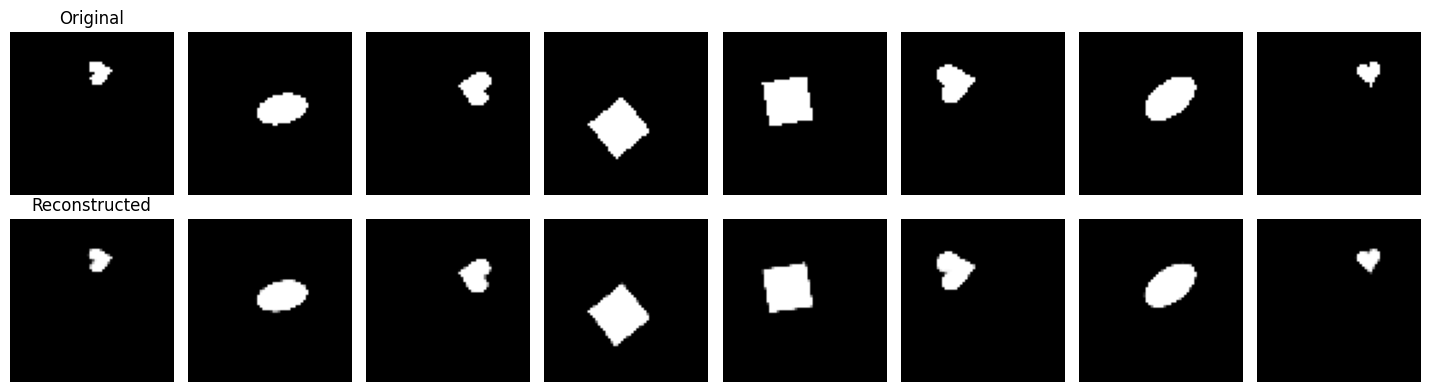

In [51]:
# ===== Model 1: AE (Autoencoder)# ================================================================

from models import Autoencoder
from train import train_or_load_autoencoder, extract_representations, get_device
from train import plot_training_history


device = get_device()

config = {
    "model_name": "Autoencoder",
    "latent_dim": 16,
    "lr": 1e-3,
    "num_epochs": 10,
    "batch_size": 128,
}

model_AE = Autoencoder(latent_dim=config["latent_dim"])

model_AE, history, checkpoint = train_or_load_autoencoder(
    model=model_AE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config["num_epochs"],
    lr=config["lr"],
    device=device,
    checkpoint_path="./checkpoints/best_autoencoder_latent16.pt",
    force_train=False, # means if we have a saved model already, we will use it
    config=config,
)

model_AE = freeze_model(model_AE)


# ------------ Optional: if i want to look at a reconstructed representation:

#
# import importlib
# import utils

# importlib.reload(utils)
from utils import show_reconstructions

show_reconstructions(model_AE, test_loader, device, n=8)

Train β-VAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-VAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 001/10 | train loss: 94.145 | train recon: 67.541 | train KL: 26.603 | val loss: 62.068 | val recon: 34.117 | val KL: 27.951
Saved checkpoint to: checkpoints/best_beta_vae_latent16_beta4.pt


Train β-VAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-VAE:   0%|          | 0/576 [00:00<?, ?it/s]

...

Val β-VAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 009/10 | train loss: 45.694 | train recon: 17.516 | train KL: 28.178 | val loss: 46.836 | val recon: 18.541 | val KL: 28.295


Train β-VAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-VAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 010/10 | train loss: 45.233 | train recon: 17.144 | train KL: 28.089 | val loss: 44.771 | val recon: 16.485 | val KL: 28.286
Saved checkpoint to: checkpoints/best_beta_vae_latent16_beta4.pt

β-VAE training complete.
Best epoch: 10
Best score: 44.771
Loaded checkpoint from: ./checkpoints/best_beta_vae_latent16_beta4.pt
Checkpoint epoch: 10
Checkpoint val loss: 44.77132


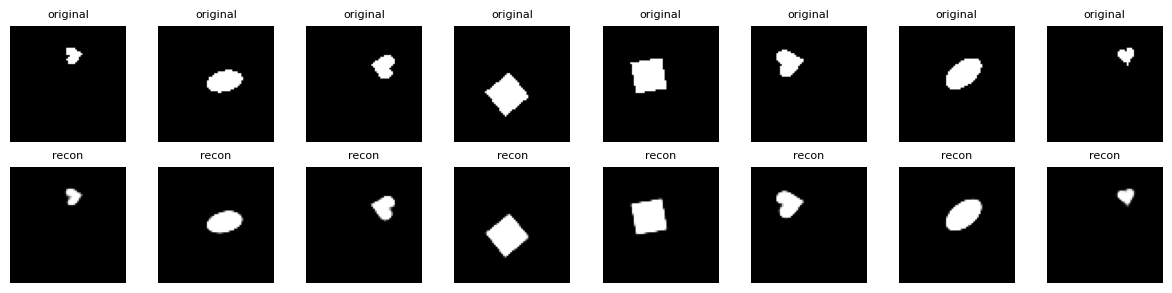

In [96]:
#========Model 2: β-VAE ============================================================

from models import BetaVAE
from train import train_or_load_beta_vae, freeze_model, get_device
from train import plot_training_history


device = get_device()

config_BVAE = {
    "model_name": "BetaVAE",
    "latent_dim": 16,
    "beta": 1.0,
    "lr": 1e-3,
    "num_epochs": 10,
    "batch_size": 128,
}

model_BVAE = BetaVAE(latent_dim=config_BVAE["latent_dim"])

model_BVAE, history_BVAE, checkpoint_BVAE = train_or_load_beta_vae(
    model=model_BVAE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config_BVAE["num_epochs"],
    lr=config_BVAE["lr"],
    beta=config_BVAE["beta"],
    device=device,
    checkpoint_path="./checkpoints/best_beta_vae_latent16_beta4.pt",
    force_train=False,
    config=config_BVAE,
)

model_BVAE = freeze_model(model_BVAE)


# Manual β-VAE reconstruction plot
batch = next(iter(test_loader))
x = batch["x"][:8].to(device)

x_recon = reconstruct_batch_beta_vae(
    model=model_BVAE,
    x=x,
    device=device,
)

x_cpu = x.detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    axes[0, i].imshow(x_cpu[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(x_recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    axes[1, i].set_title("recon", fontsize=8)

plt.tight_layout()
plt.show()

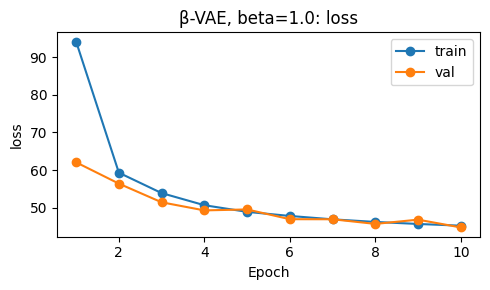

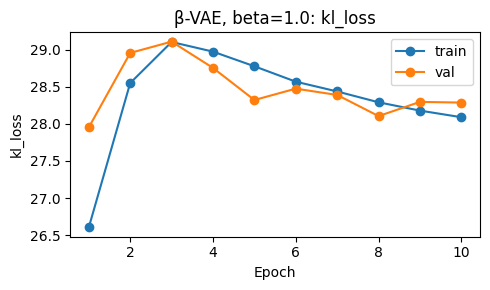

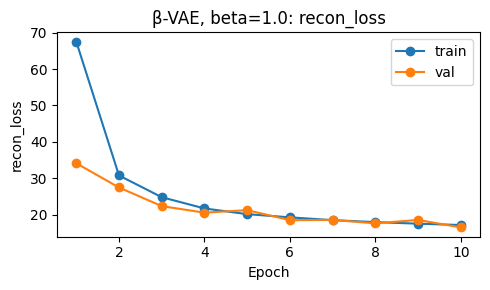

In [97]:
from train import plot_training_history

plot_training_history(
    history_BVAE,
    title=f"β-VAE, beta={config_BVAE['beta']}",
)

Train β-TCVAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-TCVAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 001/20 | train loss: 180.234 | recon: 147.690 | MI: 4.580 | TC: 3.921 | DW-KL: 4.438 | val loss: 127.243 | val recon: 93.779 | val TC: 4.583
Saved checkpoint to: checkpoints/best_beta_tcvae_latent16_tc4.pt


Train β-TCVAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-TCVAE:   0%|          | 0/576 [00:00<?, ?it/s]

...

Val β-TCVAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 019/20 | train loss: 94.867 | recon: 43.966 | MI: 4.849 | TC: 7.431 | DW-KL: 1.465 | val loss: 94.622 | val recon: 42.740 | val TC: 7.585
Saved checkpoint to: checkpoints/best_beta_tcvae_latent16_tc4.pt


Train β-TCVAE:   0%|          | 0/4608 [00:00<?, ?it/s]

Val β-TCVAE:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch 020/20 | train loss: 94.483 | recon: 43.285 | MI: 4.849 | TC: 7.477 | DW-KL: 1.485 | val loss: 94.048 | val recon: 42.469 | val TC: 7.536
Saved checkpoint to: checkpoints/best_beta_tcvae_latent16_tc4.pt

β-TCVAE training complete.
Best epoch: 20
Best score: 94.048
Loaded checkpoint from: ./checkpoints/best_beta_tcvae_latent16_tc4.pt
Checkpoint epoch: 20
Checkpoint val loss: 94.04815


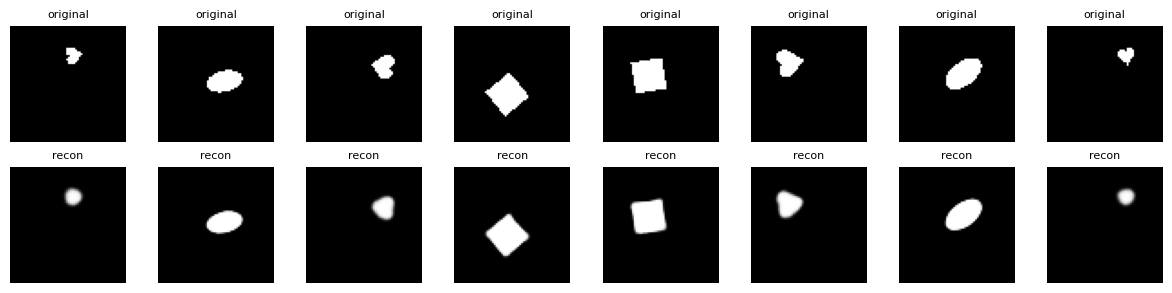

In [155]:
# ============================================================# Train / load β-TCVAE# ============================================================
from models import BetaTCVAE
from train import train_or_load_beta_tcvae, freeze_model, get_device

device = get_device()

config_BTCVAE = {
    "model_name": "BetaTCVAE",
    "latent_dim": 16,
    "alpha_mi": 1.0,
    "beta_tc": 6.0,
    "gamma_dwkl": 1.0,
    "lr": 2*1e-4,
    "num_epochs": 20,
    "batch_size": 128,
}

model_BTCVAE = BetaTCVAE(
    latent_dim=config_BTCVAE["latent_dim"],
)

model_BTCVAE, history_BTCVAE, checkpoint_BTCVAE = train_or_load_beta_tcvae(
    model=model_BTCVAE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config_BTCVAE["num_epochs"],
    lr=config_BTCVAE["lr"],
    alpha_mi=config_BTCVAE["alpha_mi"],
    beta_tc=config_BTCVAE["beta_tc"],
    gamma_dwkl=config_BTCVAE["gamma_dwkl"],
    device=device,
    checkpoint_path="./checkpoints/best_beta_tcvae_latent16_tc4.pt",
    force_train=True,
    config=config_BTCVAE,
)

model_BTCVAE = freeze_model(model_BTCVAE)


batch = next(iter(test_loader))
x = batch["x"][:8].to(device)

x_recon = reconstruct_batch_beta_tcvae(
    model=model_BTCVAE,
    x=x,
    device=device,
)

x_cpu = x.detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    axes[0, i].imshow(x_cpu[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(x_recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    axes[1, i].set_title("recon", fontsize=8)

plt.tight_layout()
plt.show()

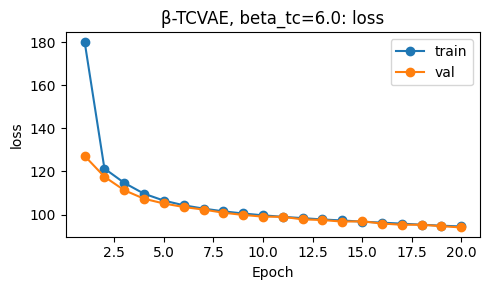

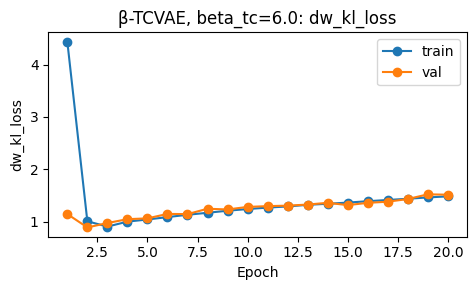

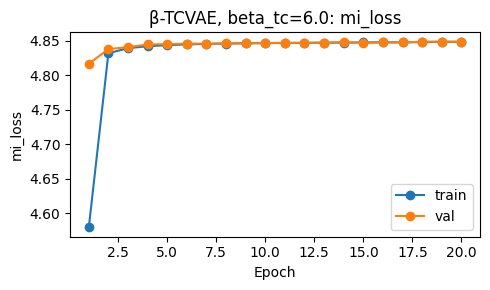

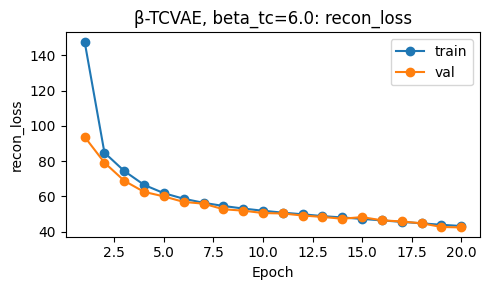

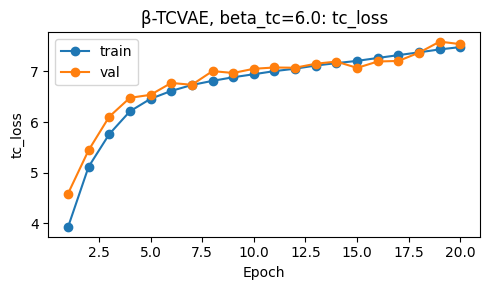

In [156]:
from train import plot_training_history

plot_training_history(
    history_BTCVAE,
    title=f"β-TCVAE, beta_tc={config_BTCVAE['beta_tc']}",
)

# 4. Define Prbes
The linear probes are defined int he probes.py

In [ ]:
from train import extract_representations
from probes import run_all_factor_probes

#A =========== first we extract for each sample (all samples for train val and test) the represetation (as Z) and the correspongin FVs ( as Y)
# ------------------------------------------------------------------for Autoencode mode (A#)
train_reps_AE = extract_representations(model=model_AE,loader=train_loader,device=device)
val_reps_AE = extract_representations( model=model_AE,loader=val_loader, device=device)
test_reps_AE = extract_representations(model=model_AE,loader=test_loader, device=device,)

Extract z:   0%|          | 0/4608 [00:00<?, ?it/s]

In [99]:
# ============================================================ Extract β-VAE representations# ============================================================
from train import extract_representations
train_reps_BVAE = extract_representations( model=model_BVAE,loader=train_loader, device=device,)
val_reps_BVAE = extract_representations( model=model_BVAE,loader=val_loader,device=device,)
test_reps_BVAE = extract_representations(  model=model_BVAE, loader=test_loader,device=device,)

Extract z:   0%|          | 0/4608 [00:00<?, ?it/s]

Extract z:   0%|          | 0/576 [00:00<?, ?it/s]

Extract z:   0%|          | 0/576 [00:00<?, ?it/s]

In [157]:
# ============================================================# Extract representations: β-TCVAE# ============================================================

train_reps_BTCVAE = extract_representations(model=model_BTCVAE,loader=train_loader,device=device,)

val_reps_BTCVAE = extract_representations(model=model_BTCVAE,loader=val_loader, device=device,)

test_reps_BTCVAE = extract_representations( model=model_BTCVAE,loader=test_loader, device=device)

Extract z:   0%|          | 0/4608 [00:00<?, ?it/s]

Extract z:   0%|          | 0/576 [00:00<?, ?it/s]

Extract z:   0%|          | 0/576 [00:00<?, ?it/s]

# 5. Disentanglement analysis

What is being trained here are the factor probes:
$$g_{\phi_k}(z_i) \approx FV_k(x_i)$$
One probe per factor "k". <br>
In our case, because we skip color, we train 5 probes:
$$g_{\phi_{\text{shape}}},\quad
g_{\phi_{\text{scale}}},\quad
g_{\phi_{\text{rotation}}},\quad
g_{\phi_{x}},\quad
g_{\phi_{y}}$$

Since hidden_dim=None, each probe is a linear classifier:
$$\hat{y}_{i,k}=g_{\phi_k}(z_i)=W_k z_i+b_k$$
where: 
$$z_i \in \mathbb{R}^{16}$$

and each output has different number of classes:
$$g_{\phi_{\text{shape}}}(z_i)\in\mathbb{R}^{3}$$
$$g_{\phi_{\text{scale}}}(z_i)\in\mathbb{R}^{6}$$
$$g_{\phi_{\text{rotation}}}(z_i)\in\mathbb{R}^{40}$$
$$g_{\phi_{x}}(z_i)\in\mathbb{R}^{32}, \qquad
g_{\phi_{y}}(z_i)\in\mathbb{R}^{32}$$

The training objective for each factor probe is:

$$\phi_k^*
=
\arg\min_{\phi_k}
\frac{1}{N_{\text{train}}}
\sum_{i=1}^{N_{\text{train}}}
\mathrm{CE}
\left(
g_{\phi_k}(z_i),
FV_k(x_i)
\right)$$
where 
$$z_i=f_\theta(x_i)$$
importnat to note that:
$$\theta \text{ is fixed}, \qquad \phi_k \text{ is trained}$$

# 5 c1. Factor probes

## c1(i)

In [100]:
# ===== Model 1: AE (Autoencoder)# ================================================================
# then we will train the probes for FVs
results_AE, probe_models_AE, probe_histories_AE = run_all_factor_probes(
                                                                            Z_train= train_reps_AE["Z"],
                                                                            Y_train=train_reps_AE["Y"],
                                                                            Z_val=val_reps_AE["Z"],
                                                                            Y_val=val_reps_AE["Y"],
                                                                            Z_test= test_reps_AE["Z"],
                                                                            Y_test=test_reps_AE["Y"],
                                                                            factor_names=dsprites['factor_names'],
                                                                            skip_factors=("color",),
                                                                            hidden_dim=None,
                                                                            num_epochs=5,
                                                                            lr=1e-3,
                                                                            batch_size=256,
                                                                            device=device )


results_AE["chance_acc"] = 1.0 / results_AE["num_classes"] # add this as what be by chance chace
results_AE["normalized_acc"] = ((results_AE["test_acc"] - results_AE["chance_acc"]) / (1.0 - results_AE["chance_acc"]))

results_AE


Skipping factor: color

Training probe for factor: shape


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 001/5 | train acc: 0.4293 | val acc: 0.4436


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

...

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 005/5 | train acc: 0.4098 | val acc: 0.4140


Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Final test accuracy for y_position: 0.4238


,factor,num_classes,best_val_acc,test_acc,test_loss,chance_acc,normalized_acc
0,shape,3,0.443631,0.442057,1.014456,0.333333,0.163086
1,scale,6,0.483222,0.481839,0.945638,0.166667,0.378206
2,rotation,40,0.060601,0.058824,3.503774,0.025000,0.034692
3,x_position,32,0.420722,0.421156,1.507015,0.031250,0.402484
4,y_position,32,0.413968,0.423842,1.505980,0.031250,0.405256


In [101]:
# ===== Model 2: β-VAE ================================================================

# Then we train the probes for FVs
results_BVAE, probe_models_BVAE, probe_histories_BVAE = run_all_factor_probes(
    Z_train=train_reps_BVAE["Z"],
    Y_train=train_reps_BVAE["Y"],
    Z_val=val_reps_BVAE["Z"],
    Y_val=val_reps_BVAE["Y"],
    Z_test=test_reps_BVAE["Z"],
    Y_test=test_reps_BVAE["Y"],
    factor_names=dsprites["factor_names"],
    skip_factors=("color",),
    hidden_dim=None,      # None = linear probe
    num_epochs=5,
    lr=1e-3,
    batch_size=256,
    device=device,
)

# Add chance accuracy
results_BVAE["chance_acc"] = 1.0 / results_BVAE["num_classes"]

# Add normalized accuracy
results_BVAE["normalized_acc"] = (
    (results_BVAE["test_acc"] - results_BVAE["chance_acc"])
    / (1.0 - results_BVAE["chance_acc"])
)

results_BVAE


Skipping factor: color

Training probe for factor: shape


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 001/5 | train acc: 0.4203 | val acc: 0.4343


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

...

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 005/5 | train acc: 0.2953 | val acc: 0.2970


Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Final test accuracy for y_position: 0.2999


,factor,num_classes,best_val_acc,test_acc,test_loss,chance_acc,normalized_acc
0,shape,3,0.436998,0.435086,1.023613,0.333333,0.152629
1,scale,6,0.497694,0.497396,0.935922,0.166667,0.396875
2,rotation,40,0.046278,0.046495,3.596126,0.025000,0.022046
3,x_position,32,0.310669,0.309299,1.943666,0.031250,0.287018
4,y_position,32,0.296956,0.299913,1.924148,0.031250,0.277330


In [158]:
# ===== Model 3: β-TCVAE ================================================================

# Then we train the probes for FVs
results_BTCVAE, probe_models_BTCVAE, probe_histories_BTCVAE = run_all_factor_probes(
    Z_train=train_reps_BTCVAE["Z"],
    Y_train=train_reps_BTCVAE["Y"],
    Z_val=val_reps_BTCVAE["Z"],
    Y_val=val_reps_BTCVAE["Y"],
    Z_test=test_reps_BTCVAE["Z"],
    Y_test=test_reps_BTCVAE["Y"],
    factor_names=dsprites["factor_names"],
    skip_factors=("color",),
    hidden_dim=None,      # None = linear probe
    num_epochs=5,
    lr=1e-3,
    batch_size=256,
    device=device,
)

# Add chance accuracy
results_BTCVAE["chance_acc"] = 1.0 / results_BTCVAE["num_classes"]

# Add normalized accuracy
results_BTCVAE["normalized_acc"] = (
    (results_BTCVAE["test_acc"] - results_BTCVAE["chance_acc"])
    / (1.0 - results_BTCVAE["chance_acc"])
)

results_BTCVAE


Skipping factor: color

Training probe for factor: shape


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 001/5 | train acc: 0.4477 | val acc: 0.4614


Train probe:   0%|          | 0/2304 [00:00<?, ?it/s]

...

Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Epoch 005/5 | train acc: 0.2984 | val acc: 0.3058


Eval probe:   0%|          | 0/288 [00:00<?, ?it/s]

Final test accuracy for y_position: 0.3073


,factor,num_classes,best_val_acc,test_acc,test_loss,chance_acc,normalized_acc
0,shape,3,0.481988,0.479058,1.005079,0.333333,0.218587
1,scale,6,0.478611,0.476617,1.067736,0.166667,0.371940
2,rotation,40,0.205037,0.203084,2.869155,0.025000,0.182651
3,x_position,32,0.296441,0.295044,2.236222,0.031250,0.272303
4,y_position,32,0.305840,0.307278,2.228893,0.031250,0.284932


## 5.c.1(ii)
for heatmap will train one small probe for each pair:
$$z_m \rightarrow FV_k(x)$$
and each heatmap entry is:
$$H_{k,m}=\text{Accuracy}\left(g_{\phi_{k,m}}(z_m), FV_k(x)\right)$$

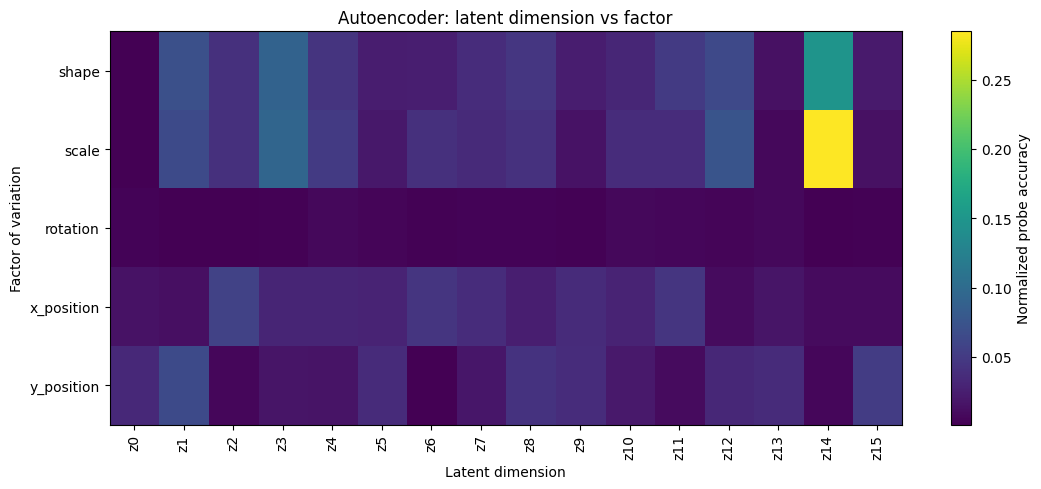

In [51]:
# ===== Model 1: AE (Autoencoder)# ================================================================
import probes
importlib.reload(probes)
from probes import run_latent_factor_heatmap

H_AE, heatmap_factors_AE, heatmap_records_AE = run_latent_factor_heatmap(
                                                                            Z_train= train_reps_AE["Z"],
                                                                            Y_train=train_reps_AE["Y"],
                                                                            Z_val=val_reps_AE["Z"],
                                                                            Y_val=val_reps_AE["Y"],
                                                                            Z_test= test_reps_AE["Z"],
                                                                            Y_test=test_reps_AE["Y"],
                                                                            factor_names=dsprites["factor_names"],
                                                                            model_name="Autoencoder",
                                                                            skip_factors=("color",),
                                                                            num_epochs=3,
                                                                            lr=1e-2,
                                                                            batch_size=256,
                                                                            score_type="normalized_test_acc",
                                                                            device=device,
                                                                            verbose=False,
                                                                        )

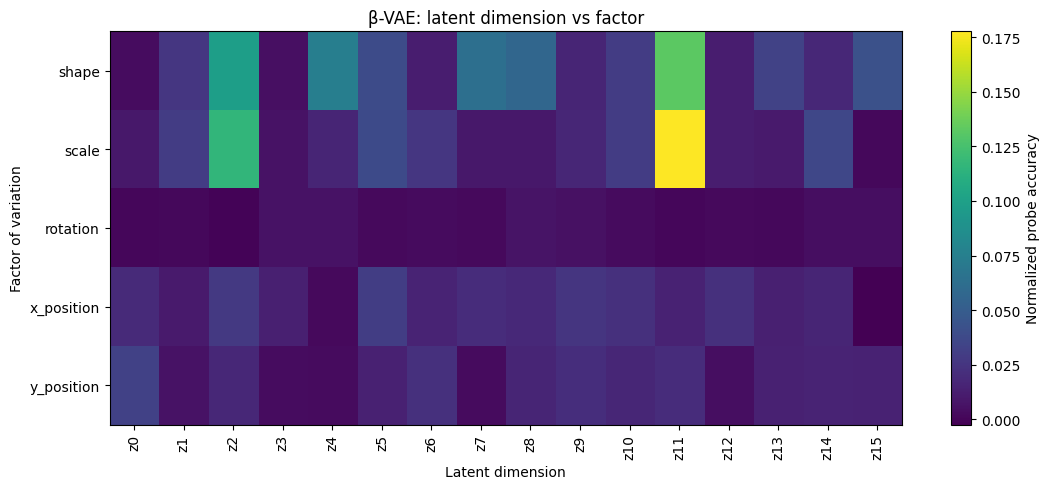

In [102]:
# ===== Model 2: β-VAE latent-dimension vs factor heatmap ===============================

import probes
importlib.reload(probes)

from probes import run_latent_factor_heatmap

H_BVAE, heatmap_factors_BVAE, heatmap_records_BVAE = run_latent_factor_heatmap(
    Z_train=train_reps_BVAE["Z"],
    Y_train=train_reps_BVAE["Y"],
    Z_val=val_reps_BVAE["Z"],
    Y_val=val_reps_BVAE["Y"],
    Z_test=test_reps_BVAE["Z"],
    Y_test=test_reps_BVAE["Y"],
    factor_names=dsprites["factor_names"],
    model_name="β-VAE",
    skip_factors=("color",),
    num_epochs=3,
    lr=1e-2,
    batch_size=256,
    score_type="normalized_test_acc",
    device=device,
    verbose=False,
)

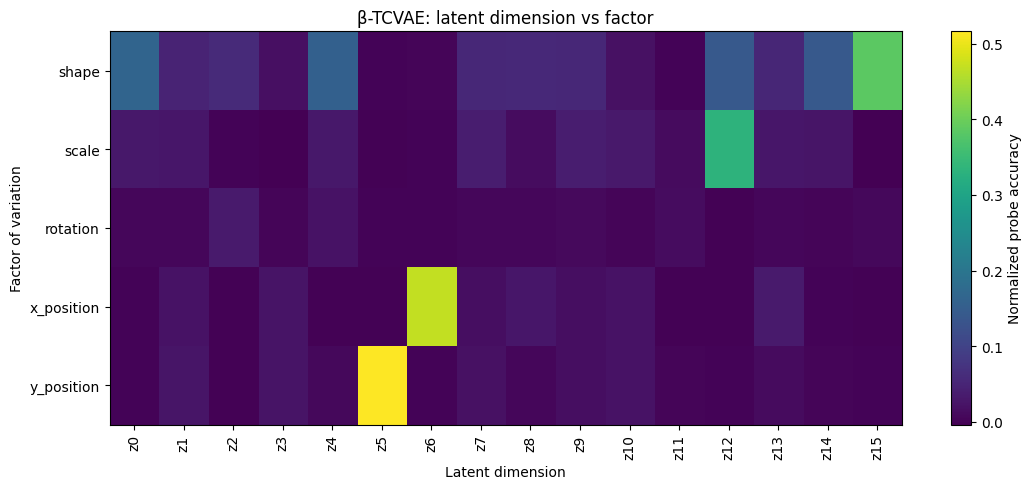

In [159]:
# ===== Model 3: β-TCVAE latent-dimension vs factor heatmap ===============================

import probes
importlib.reload(probes)

from probes import run_latent_factor_heatmap

H_BTCVAE, heatmap_factors_BTCVAE, heatmap_records_BTCVAE = run_latent_factor_heatmap(
    Z_train=train_reps_BTCVAE["Z"],
    Y_train=train_reps_BTCVAE["Y"],
    Z_val=val_reps_BTCVAE["Z"],
    Y_val=val_reps_BTCVAE["Y"],
    Z_test=test_reps_BTCVAE["Z"],
    Y_test=test_reps_BTCVAE["Y"],
    factor_names=dsprites["factor_names"],
    model_name="β-TCVAE",
    skip_factors=("color",),
    num_epochs=3,
    lr=1e-2,
    batch_size=256,
    score_type="normalized_test_acc",
    device=device,
    verbose=False,
)

In [142]:
H_BTCVAE

tensor([[ 5.8695e-02,  7.8206e-02,  1.9307e-02,  5.9163e-02,  6.8156e-02,
          8.8826e-02,  5.5908e-02,  1.6174e-02,  1.8250e-02,  4.6326e-02,
          3.2756e-03,  4.8584e-02,  5.4749e-02,  1.6744e-02,  2.7059e-03,
          5.1310e-02],
        [ 6.8962e-02,  9.3001e-02,  1.7220e-02,  7.6725e-02,  8.9258e-02,
         -2.3112e-03,  3.5319e-03,  2.2038e-02,  2.0931e-02,  9.6029e-03,
          1.3216e-02,  6.5934e-02,  1.5788e-02,  2.5195e-02, -2.4902e-03,
          7.2331e-02],
        [ 1.0127e-03,  2.6403e-03,  3.9480e-03,  3.6002e-03,  1.8335e-03,
          4.4627e-03,  5.3947e-03,  2.9046e-03,  1.8196e-03, -2.7822e-06,
          2.1952e-03,  1.9587e-03,  3.8645e-03,  4.1427e-03,  1.1349e-02,
          6.3685e-03],
        [ 1.9027e-02,  8.2045e-03, -9.5206e-04,  1.6325e-02,  2.0119e-02,
          1.1285e-02,  1.8201e-02,  1.4351e-02,  7.8097e-02,  9.4786e-03,
          2.4600e-02,  2.1113e-02,  1.1859e-02,  1.6059e-02,  2.6042e-03,
          1.0823e-02],
        [ 3.1194e-02

# 5.c.2 Latent traversal:

In [103]:
# Load traversal utilities
import importlib
import torch

import traversal
importlib.reload(traversal)

from traversal import (
    get_sample_from_loader,
    get_sample_by_factor,
    factor_vector_to_dict,
    plot_coordinate_traversal,
    plot_pca_traversal,
    plot_pca_explained_variance,
    get_factor_direction,
    plot_factor_supervised_traversal,
)

In [76]:
# ===== Model 1: AE (Autoencoder)# ================================================================
#  Pick one base image from the test set

x_base_AE, y_base_AE, y_values_base_AE = get_sample_from_loader(
    loader=test_loader,
    sample_index=10000,
    device=device,
)

print("Base sample factors:")
print(factor_vector_to_dict(y_base_AE, dsprites["factor_names"]))

Base sample factors:
{'color': 0, 'shape': 1, 'scale': 3, 'rotation': 10, 'x_position': 22, 'y_position': 10}


In [77]:
# ===== Model 2: β-VAE ================================================================
# Pick the same base image from the test set for fair comparison with AE

import traversal
importlib.reload(traversal)

from traversal import (
    get_sample_from_loader,
    plot_coordinate_traversal,
    factor_vector_to_dict,
)

x_base_BVAE, y_base_BVAE, y_values_base_BVAE = get_sample_from_loader(
    loader=test_loader,
    sample_index=10000,
    device=device,
)

In [160]:
# ===== Model 3: β-TCVAE ================================================================
# Pick the same base image from the test set for fair comparison with AE and β-VAE

from traversal import (
    get_sample_from_loader,
    plot_coordinate_traversal,
    factor_vector_to_dict,
)

x_base_BTCVAE, y_base_BTCVAE, y_values_base_BTCVAE = get_sample_from_loader(
    loader=test_loader,
    sample_index=10000,
    device=device,
)


## 5.c.2.A. Coordinate directions
This follows our slide:
$$u_m=e_m$$
$$z'(t)=z+t e_m$$
Use dimensions that looked interesting in the heatmap. <br>
Note that Here t is measured in units of $$std(z_m)$$

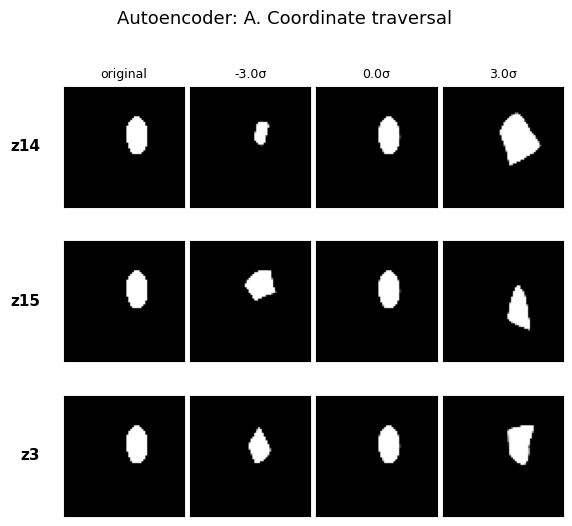

In [78]:
# ===== Model 1: AE (Autoencoder)# ================================================================
import traversal
importlib.reload(traversal)
from traversal import plot_coordinate_traversal

dims_to_traverse_AE = [14, 15,3] # these were interesting to check for the AE

coord_images_AE, coord_t_values_AE = plot_coordinate_traversal(
    model=model_AE,
    x_base=x_base_AE,
    Z_reference=train_reps_AE["Z"],
    dims=dims_to_traverse_AE,
    n_steps=3,
    alpha_min=-3.0,
    alpha_max=3.0,
    model_name="Autoencoder",
    device=device,
)

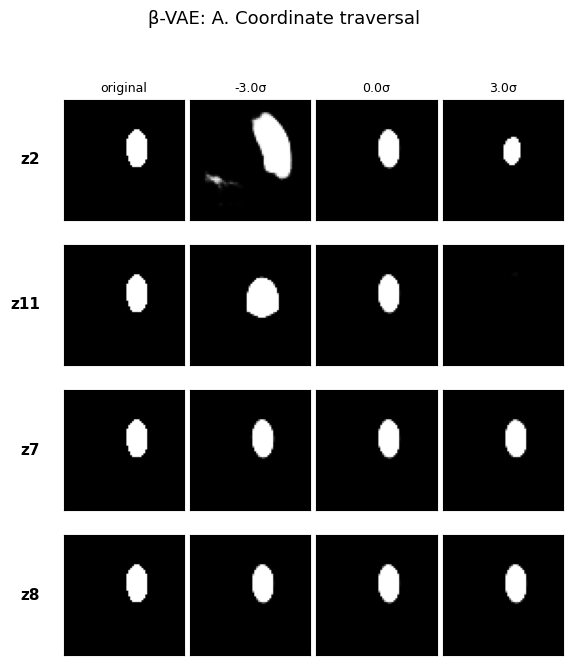

Base sample factors:
{'color': 0, 'shape': 1, 'scale': 3, 'rotation': 10, 'x_position': 22, 'y_position': 10}


In [176]:
# ===== Model 2: β-VAE ================================================================
# Choose latent dimensions to traverse.
# Ideally choose these based on the β-VAE heatmap H_BVAE.
dims_to_traverse_BVAE = [2, 11, 7,8]   # replace with interesting β-VAE dims

coord_images_BVAE, coord_t_values_BVAE = plot_coordinate_traversal(
    model=model_BVAE,
    x_base=x_base_BVAE,
    Z_reference=train_reps_BVAE["Z"],
    dims=dims_to_traverse_BVAE,
    n_steps=3,
    alpha_min=-3.0,
    alpha_max=3.0,
    model_name="β-VAE",
    device=device,
)

print("Base sample factors:")
print(factor_vector_to_dict(y_base_BVAE, dsprites["factor_names"]))

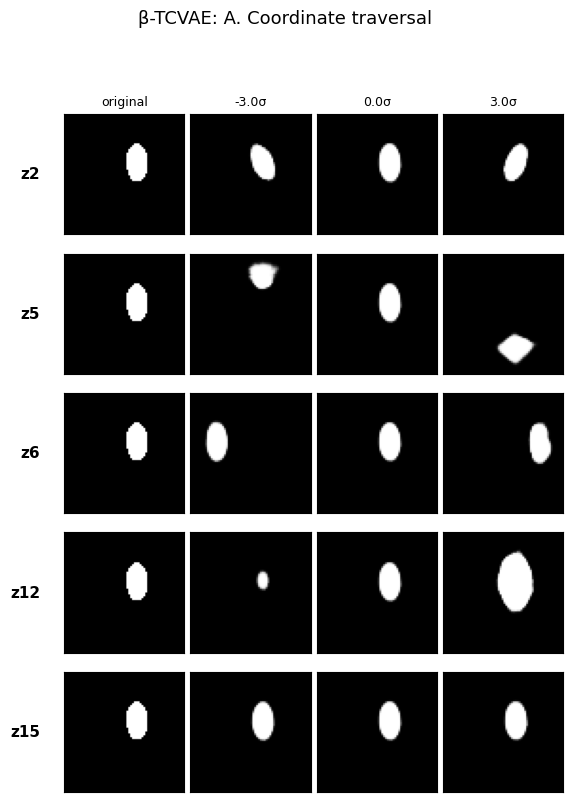

Base sample factors:
{'color': 0, 'shape': 1, 'scale': 3, 'rotation': 10, 'x_position': 22, 'y_position': 10}


In [177]:
# ===== Model 3: β-TCVAE ================================================================
# Choose latent dimensions to traverse.
# Ideally choose these based on the β-TCVAE heatmap H_BTCVAE.

dims_to_traverse_BTCVAE = [2, 5,6, 12, 15]   # replace with interesting β-TCVAE dims

coord_images_BTCVAE, coord_t_values_BTCVAE = plot_coordinate_traversal(
    model=model_BTCVAE,
    x_base=x_base_BTCVAE,
    Z_reference=train_reps_BTCVAE["Z"],
    dims=dims_to_traverse_BTCVAE,
    n_steps=3,
    alpha_min=-3.0,
    alpha_max=3.0,
    model_name="β-TCVAE",
    device=device,
)

print("Base sample factors:")
print(factor_vector_to_dict(y_base_BTCVAE, dsprites["factor_names"]))

## 5.c.2.B. PCA directions
This follows our slide:
$$u_m=\mathrm{PCA}_m(Z)$$
$$z'(t)=z+t u_m$$

Here t is measured in units of $$std(PC score)$$

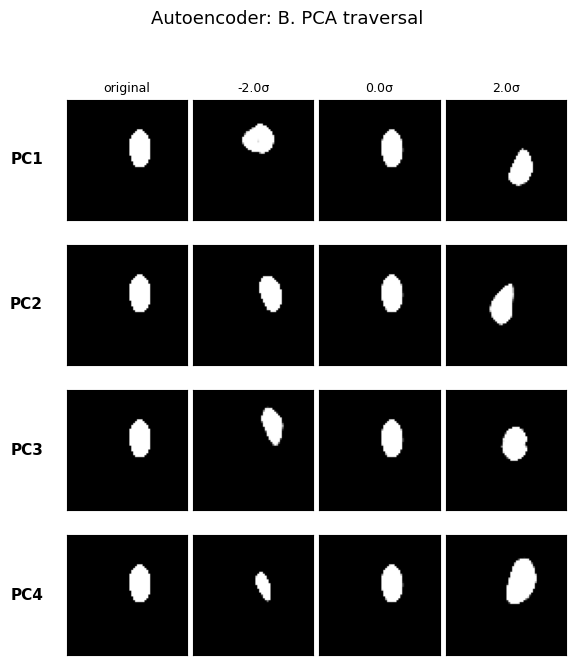

In [178]:
# ===== Model 1: AE (Autoencoder)# ================================================================
pca_images_AE, pca_t_values_AE, pca_info_AE = plot_pca_traversal(
    model=model_AE,
    x_base=x_base_AE,
    Z_reference=train_reps_AE["Z"],
    pc_indices=(0, 1, 2, 3),
    n_steps=3,
    alpha_min=-2.0,
    alpha_max=2.0,
    model_name="Autoencoder",
    device=device,
)

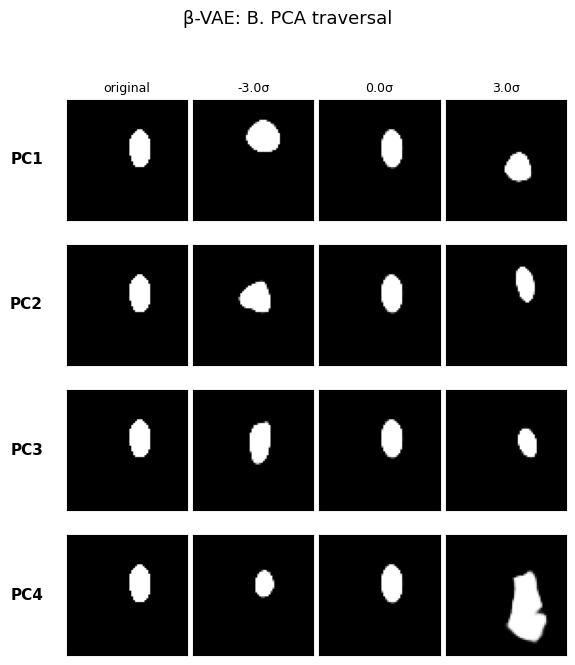

In [179]:
# ===== Model 2: β-VAE ================================================================

pca_images_BVAE, pca_t_values_BVAE, pca_info_BVAE = plot_pca_traversal(
    model=model_BVAE,
    x_base=x_base_BVAE,
    Z_reference=train_reps_BVAE["Z"],
    pc_indices=(0, 1, 2, 3),
    n_steps=3,
    alpha_min=-3.0,
    alpha_max=3.0,
    model_name="β-VAE",
    device=device,
)

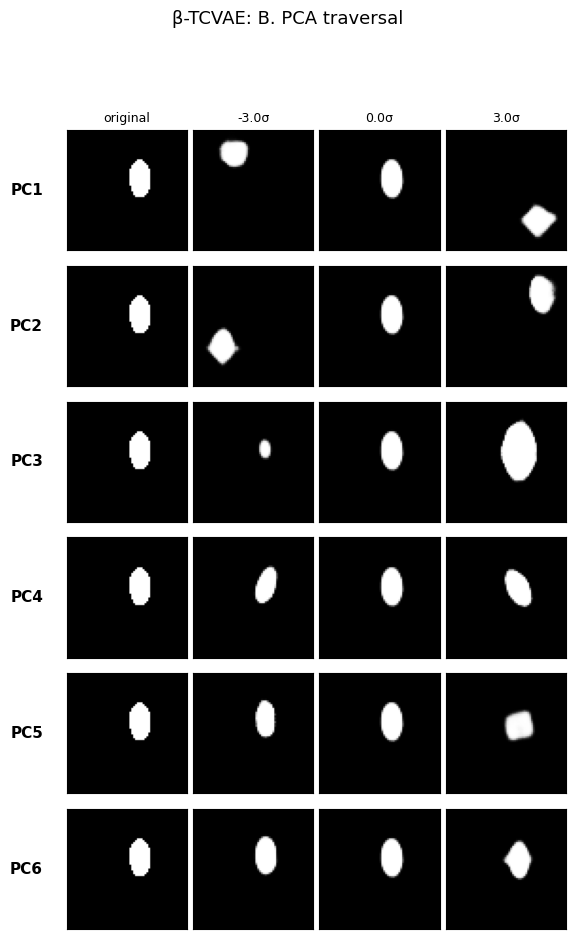

In [180]:
# ===== Model 3: β-TCVAE ================================================================

pca_images_BTCVAE, pca_t_values_BTCVAE, pca_info_BTCVAE = plot_pca_traversal(
    model=model_BTCVAE,
    x_base=x_base_BTCVAE,
    Z_reference=train_reps_BTCVAE["Z"],
    pc_indices=(0, 1, 2, 3,4,5),
    n_steps=3,
    alpha_min=-3.0,
    alpha_max=3.0,
    model_name="β-TCVAE",
    device=device,
)

## 5.c.2.C. Factor-supervised directions
we First encode all samples:
$$z_i=f_\theta(x_i)$$
For factor FV_k we calcute the mean:
$$\mu_{k,c}
=
\frac{1}{N_c}
\sum_{i:FV_k(x_i)=c} z_i$$
and based on it define the direction:
$$u_k=\mu_{k,C_k-1}-\mu_{k,0}$$
or more clearly:
$$u_{a\rightarrow b}=\mu_{k,b}-\mu_{k,a}$$

### 5.c.2.C. Example 1: Scale traversal
$$u_{\text{scale}}
=
\mu_{\text{scale},5}
-
\mu_{\text{scale},0}$$

{'factor_name': 'scale', 'start_value': 0, 'end_value': 5, 'direction_norm_before_normalization': 28.380992889404297, 'normalize': False}
Base scale sample:
{'color': 0, 'shape': 2, 'scale': 0, 'rotation': 11, 'x_position': 19, 'y_position': 0}


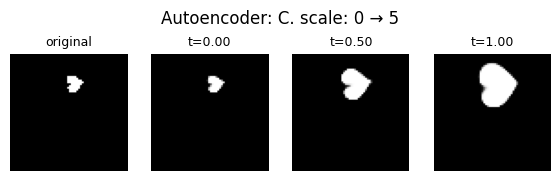

In [112]:
# ===== Model 1: AE (Autoencoder)# ================================================================


u_scale_AE, info_scale_AE = get_factor_direction(
    Z=train_reps_AE["Z"],
    Y=train_reps_AE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    start_value=0,
    end_value=5,
    normalize=False,
)

print(info_scale_AE)

# Pick a base image with scale = 0
x_scale0_AE, y_scale0_AE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    factor_value=0,
    device=device,
)

print("Base scale sample:")
print(factor_vector_to_dict(y_scale0_AE, dsprites["factor_names"]))

scale_images_AE = plot_factor_supervised_traversal(
    model=model_AE,
    x_base=x_scale0_AE,
    direction=u_scale_AE,
    direction_name="scale: 0 → 5",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="Autoencoder",
    device=device,
)

{'factor_name': 'scale', 'start_value': 0, 'end_value': 5, 'direction_norm_before_normalization': 2.7248408794403076, 'normalize': False}
Base scale sample:
{'color': 0, 'shape': 2, 'scale': 0, 'rotation': 11, 'x_position': 19, 'y_position': 0}


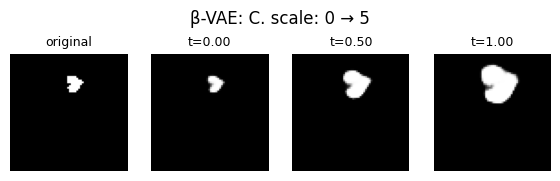

In [119]:
# ===== Model 2: β-VAE ================================================================

u_scale_BVAE, info_scale_BVAE = get_factor_direction(
    Z=train_reps_BVAE["Z"],
    Y=train_reps_BVAE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    start_value=0,
    end_value=5,
    normalize=False,
)

print(info_scale_BVAE)

# Pick a base image with scale = 0
x_scale0_BVAE, y_scale0_BVAE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    factor_value=0,
    device=device,
)

print("Base scale sample:")
print(factor_vector_to_dict(y_scale0_BVAE, dsprites["factor_names"]))

scale_images_BVAE = plot_factor_supervised_traversal(
    model=model_BVAE,
    x_base=x_scale0_BVAE,
    direction=u_scale_BVAE,
    direction_name="scale: 0 → 5",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="β-VAE",
    device=device,
)

{'factor_name': 'scale', 'start_value': 0, 'end_value': 5, 'direction_norm_before_normalization': 2.640103816986084, 'normalize': False}
Base scale sample:
{'color': 0, 'shape': 2, 'scale': 0, 'rotation': 11, 'x_position': 19, 'y_position': 0}


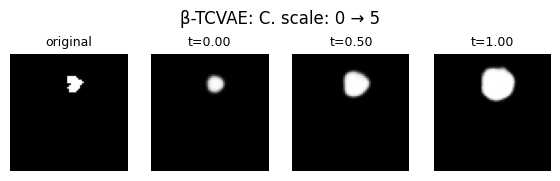

In [181]:
# ===== Model 3: β-TCVAE ================================================================

u_scale_BTCVAE, info_scale_BTCVAE = get_factor_direction(
    Z=train_reps_BTCVAE["Z"],
    Y=train_reps_BTCVAE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    start_value=0,
    end_value=5,
    normalize=False,
)

print(info_scale_BTCVAE)

# Pick a base image with scale = 0
x_scale0_BTCVAE, y_scale0_BTCVAE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="scale",
    factor_value=0,
    device=device,
)

print("Base scale sample:")
print(factor_vector_to_dict(y_scale0_BTCVAE, dsprites["factor_names"]))

scale_images_BTCVAE = plot_factor_supervised_traversal(
    model=model_BTCVAE,
    x_base=x_scale0_BTCVAE,
    direction=u_scale_BTCVAE,
    direction_name="scale: 0 → 5",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="β-TCVAE",
    device=device,
)

### 5.c.2.C. Example 2: X position
$$u_x
=
\mu_{x,31}
-
\mu_{x,0}$$

{'factor_name': 'x_position', 'start_value': 0, 'end_value': 31, 'direction_norm_before_normalization': 37.54438781738281, 'normalize': False}
Base x-position sample:
{'color': 0, 'shape': 0, 'scale': 0, 'rotation': 20, 'x_position': 0, 'y_position': 5}


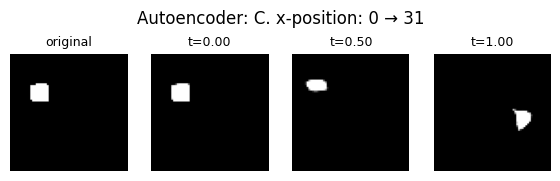

In [182]:
# ===== Model 1: AE (Autoencoder)# ================================================================

u_x_AE, info_x_AE = get_factor_direction(
    Z=train_reps_AE["Z"],
    Y=train_reps_AE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    start_value=0,
    end_value=31,
    normalize=False,
)

print(info_x_AE)

# Pick a base image with x_position = 0
x_left_AE, y_left_AE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    factor_value=0,
    device=device,
)

print("Base x-position sample:")
print(factor_vector_to_dict(y_left_AE, dsprites["factor_names"]))

xpos_images_AE = plot_factor_supervised_traversal(
    model=model_AE,
    x_base=x_left_AE,
    direction=u_x_AE,
    direction_name="x-position: 0 → 31",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="Autoencoder",
    device=device,
)

{'factor_name': 'x_position', 'start_value': 0, 'end_value': 31, 'direction_norm_before_normalization': 0.9784075617790222, 'normalize': False}
Base x-position sample:
{'color': 0, 'shape': 0, 'scale': 0, 'rotation': 20, 'x_position': 0, 'y_position': 5}


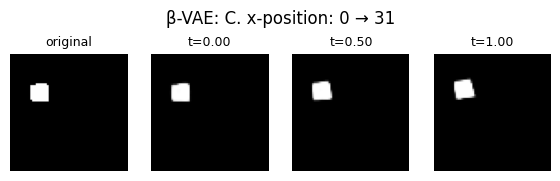

In [183]:
# ===== Model 2: β-VAE ================================================================

u_x_BVAE, info_x_BVAE = get_factor_direction(
    Z=train_reps_BVAE["Z"],
    Y=train_reps_BVAE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    start_value=0,
    end_value=31,
    normalize=False,
)

print(info_x_BVAE)

# Pick a base image with x_position = 0
x_left_BVAE, y_left_BVAE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    factor_value=0,
    device=device,
)

print("Base x-position sample:")
print(factor_vector_to_dict(y_left_BVAE, dsprites["factor_names"]))

xpos_images_BVAE = plot_factor_supervised_traversal(
    model=model_BVAE,
    x_base=x_left_BVAE,
    direction=u_x_BVAE,
    direction_name="x-position: 0 → 31",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="β-VAE",
    device=device,
)

{'factor_name': 'x_position', 'start_value': 0, 'end_value': 31, 'direction_norm_before_normalization': 4.377686023712158, 'normalize': False}
Base x-position sample:
{'color': 0, 'shape': 0, 'scale': 0, 'rotation': 20, 'x_position': 0, 'y_position': 5}


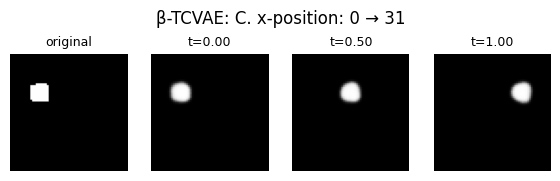

In [184]:
# ===== Model 3: β-TCVAE ================================================================

u_x_BTCVAE, info_x_BTCVAE = get_factor_direction(
    Z=train_reps_BTCVAE["Z"],
    Y=train_reps_BTCVAE["Y"],
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    start_value=0,
    end_value=31,
    normalize=False,
)

print(info_x_BTCVAE)

# Pick a base image with x_position = 0
x_left_BTCVAE, y_left_BTCVAE, _ = get_sample_by_factor(
    loader=test_loader,
    factor_names=dsprites["factor_names"],
    factor_name="x_position",
    factor_value=0,
    device=device,
)

print("Base x-position sample:")
print(factor_vector_to_dict(y_left_BTCVAE, dsprites["factor_names"]))

xpos_images_BTCVAE = plot_factor_supervised_traversal(
    model=model_BTCVAE,
    x_base=x_left_BTCVAE,
    direction=u_x_BTCVAE,
    direction_name="x-position: 0 → 31",
    t_values=torch.linspace(0.0, 1.0, 3),
    model_name="β-TCVAE",
    device=device,
)

# 5. c3. Ablation.

shape        | baseline normalized_acc: 0.163
scale        | baseline normalized_acc: 0.378
rotation     | baseline normalized_acc: 0.035
x_position   | baseline normalized_acc: 0.402
y_position   | baseline normalized_acc: 0.405


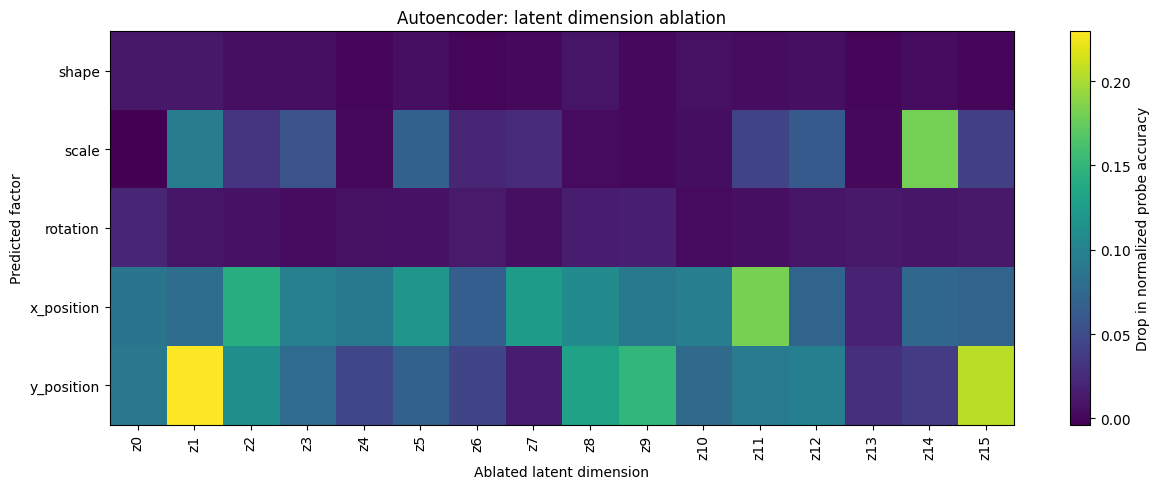

,factor,dim,num_classes,baseline_acc,ablated_acc,baseline_score,ablated_score,drop,score_type
0,rotation,0,40,0.058824,0.038140,0.034692,0.013477,0.021214,normalized_acc
1,rotation,9,40,0.058824,0.042236,0.034692,0.017678,0.017013,normalized_acc
2,rotation,8,40,0.058824,0.043823,0.034692,0.019306,0.015386,normalized_acc
3,scale,14,6,0.481839,0.331217,0.378206,0.197461,0.180745,normalized_acc
4,scale,1,6,0.481839,0.402601,0.378206,0.283122,0.095085,normalized_acc
5,scale,5,6,0.481839,0.424832,0.378206,0.309798,0.068408,normalized_acc
6,shape,0,3,0.442057,0.434340,0.163086,0.151510,0.011576,normalized_acc
7,shape,1,3,0.442057,0.434435,0.163086,0.151652,0.011434,normalized_acc
8,shape,8,3,0.442057,0.435750,0.163086,0.153625,0.009460,normalized_acc
9,x_position,11,32,0.421156,0.245348,0.402484,0.221004,0.181480,normalized_acc


In [126]:
# ============================================================Model 1: Autoencoder============================================================

import importlib
import ablation
importlib.reload(ablation)

from ablation import (
    run_latent_dimension_ablation,
    plot_ablation_heatmap,
    get_top_ablation_dimensions,
)

A_AE, ablation_factors_AE, ablation_records_AE = run_latent_dimension_ablation(
    Z_train=train_reps_AE["Z"],
    Z_test=test_reps_AE["Z"],
    Y_test=test_reps_AE["Y"],
    probe_models=probe_models_AE,
    factor_names=dsprites["factor_names"],
    skip_factors=("color",),
    batch_size=512,
    device=device,
    score_type="normalized_acc",
    verbose=True,
)

plot_ablation_heatmap(
    A=A_AE,
    factor_names=ablation_factors_AE,
    title="Autoencoder: latent dimension ablation",
    score_label="Drop in normalized probe accuracy",
)

top_ablation_AE = get_top_ablation_dimensions(
    ablation_records=ablation_records_AE,
    top_k=3,
)

top_ablation_AE

shape        | baseline normalized_acc: 0.153
scale        | baseline normalized_acc: 0.397
rotation     | baseline normalized_acc: 0.022
x_position   | baseline normalized_acc: 0.287
y_position   | baseline normalized_acc: 0.277


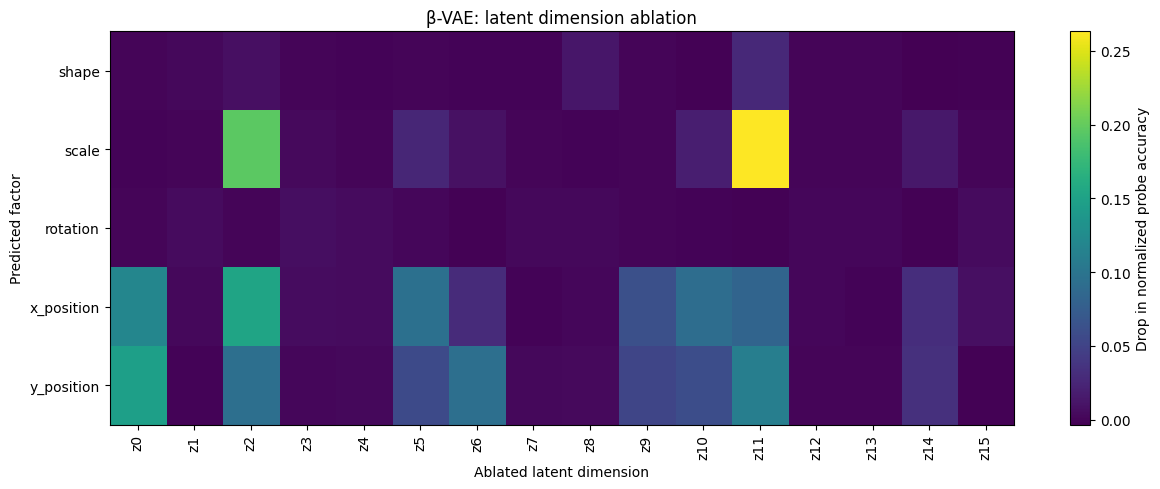

,factor,dim,num_classes,baseline_acc,ablated_acc,baseline_score,ablated_score,drop,score_type
0,rotation,3,40,0.046495,0.039985,0.022046,0.015369,0.006677,normalized_acc
1,rotation,15,40,0.046495,0.041775,0.022046,0.017205,0.004841,normalized_acc
2,rotation,4,40,0.046495,0.042345,0.022046,0.017790,0.004257,normalized_acc
3,scale,11,6,0.497396,0.278130,0.396875,0.133757,0.263118,normalized_acc
4,scale,2,6,0.497396,0.334012,0.396875,0.200814,0.196061,normalized_acc
5,scale,5,6,0.497396,0.476522,0.396875,0.371826,0.025049,normalized_acc
6,shape,11,3,0.435086,0.416612,0.152629,0.124919,0.027710,normalized_acc
7,shape,8,3,0.435086,0.426297,0.152629,0.139445,0.013184,normalized_acc
8,shape,2,3,0.435086,0.430108,0.152629,0.145162,0.007467,normalized_acc
9,x_position,2,32,0.309299,0.162259,0.287018,0.135235,0.151784,normalized_acc


In [127]:
# ============================================================ Model 2: β-VAE============================================================

A_BVAE, ablation_factors_BVAE, ablation_records_BVAE = run_latent_dimension_ablation(
    Z_train=train_reps_BVAE["Z"],
    Z_test=test_reps_BVAE["Z"],
    Y_test=test_reps_BVAE["Y"],
    probe_models=probe_models_BVAE,
    factor_names=dsprites["factor_names"],
    skip_factors=("color",),
    batch_size=512,
    device=device,
    score_type="normalized_acc",
    verbose=True,
)

plot_ablation_heatmap(
    A=A_BVAE,
    factor_names=ablation_factors_BVAE,
    title="β-VAE: latent dimension ablation",
    score_label="Drop in normalized probe accuracy",
)

top_ablation_BVAE = get_top_ablation_dimensions(
    ablation_records=ablation_records_BVAE,
    top_k=3,
)

top_ablation_BVAE

shape        | baseline normalized_acc: 0.219
scale        | baseline normalized_acc: 0.372
rotation     | baseline normalized_acc: 0.183
x_position   | baseline normalized_acc: 0.272
y_position   | baseline normalized_acc: 0.285


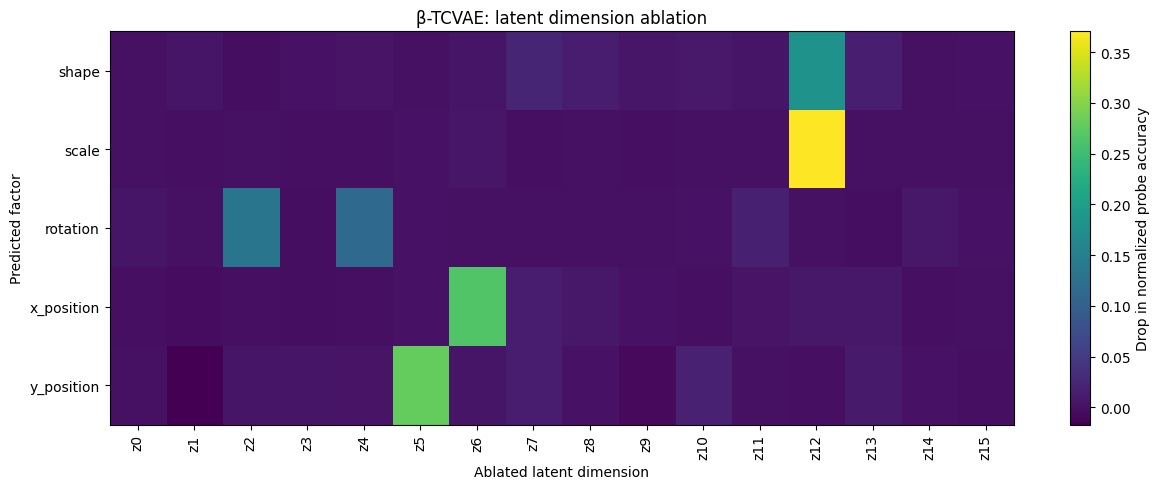

,factor,dim,num_classes,baseline_acc,ablated_acc,baseline_score,ablated_score,drop,score_type
0,rotation,2,40,0.203084,0.072618,0.182651,0.048839,0.133811,normalized_acc
1,rotation,4,40,0.203084,0.090508,0.182651,0.067188,0.115463,normalized_acc
2,rotation,11,40,0.203084,0.186049,0.182651,0.165178,0.017472,normalized_acc
3,scale,12,6,0.476617,0.167901,0.371940,0.001481,0.370459,normalized_acc
4,scale,6,6,0.476617,0.470703,0.371940,0.364844,0.007096,normalized_acc
5,scale,5,6,0.476617,0.475627,0.371940,0.370752,0.001188,normalized_acc
6,shape,12,3,0.479058,0.359158,0.218587,0.038737,0.179850,normalized_acc
7,shape,7,3,0.479058,0.463447,0.218587,0.195170,0.023417,normalized_acc
8,shape,13,3,0.479058,0.469076,0.218587,0.203613,0.014974,normalized_acc
9,x_position,6,32,0.295044,0.037910,0.272303,0.006874,0.265429,normalized_acc


In [166]:
# ============================================================# Model 3: β-TCVAE# ============================================================

A_BTCVAE, ablation_factors_BTCVAE, ablation_records_BTCVAE = run_latent_dimension_ablation(
    Z_train=train_reps_BTCVAE["Z"],
    Z_test=test_reps_BTCVAE["Z"],
    Y_test=test_reps_BTCVAE["Y"],
    probe_models=probe_models_BTCVAE,
    factor_names=dsprites["factor_names"],
    skip_factors=("color",),
    batch_size=512,
    device=device,
    score_type="normalized_acc",
    verbose=True,
)

plot_ablation_heatmap(
    A=A_BTCVAE,
    factor_names=ablation_factors_BTCVAE,
    title="β-TCVAE: latent dimension ablation",
    score_label="Drop in normalized probe accuracy",
)

top_ablation_BTCVAE = get_top_ablation_dimensions(
    ablation_records=ablation_records_BTCVAE,
    top_k=3,
)

top_ablation_BTCVAE